In [1]:
import tqdm
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


import MDAnalysis
from scipy.spatial import distance

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#PRE
u_unbound_pre_S1=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM1_dt1000.pdb'%prefix_path)
u_unbound_pre_S2=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM2_dt1000.pdb'%prefix_path)
u_unbound_pre_S3=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM3_dt1000.pdb'%prefix_path)


#UNB
u_unbound_ER_S1 = MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)

#BND
u_bound_ER_S1 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM1_dt1000.pdb"%prefix_path)
u_bound_ER_S2 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM2_dt1000.pdb"%prefix_path)
u_bound_ER_S3 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM3_dt1000.pdb"%prefix_path)





# HP1

In [3]:
HP1=[19,23,32,34,51,53,108]
terminal_atoms_sim=['CG','CD','CG','CD','NZ','CD1','CZ']
# terminal_atoms_crystal=['CG','CD1','CG','CD1','NZ','CD1','CZ']
def four_point_dist_hp1(traj):
    total_frames=len(traj.trajectory)
    n1=len(HP1)
    dist_sum = np.zeros((n1, n1))
    
    dis_19_C_ls=[]
    dis_23_C_ls=[]
    dis_32_C_ls=[]
    dis_34_C_ls=[]
    dis_51_C_ls=[]
    dis_53_C_ls=[]
    dis_108_C_ls=[]
    mean_HP1_four_point=[]
    mean_HP1_all=[]
    
    for ts in tqdm.tqdm(traj.trajectory):
        SC_COG_HP1=[]
        pocket_COG=[]
        sel2=traj.select_atoms('resid 19 or resid 23 or resid 32 or resid 34 or resid 51 or resid 53 or resid 108').center_of_geometry()
        pocket_COG.append(sel2)
        
        for i,j in zip (HP1,terminal_atoms_sim):
            sel1 = traj.select_atoms( 'resid %d and name %s'%(i,j)).center_of_geometry()
            SC_COG_HP1.append(sel1)
        
        SC_COG_HP1=np.asarray(SC_COG_HP1)
        pocket_COG=np.asarray(pocket_COG)
        ts_dist = distance.cdist(pocket_COG,SC_COG_HP1, 'euclidean')
        ts_dist=np.transpose(ts_dist)

        dis_19_C=ts_dist[0,0]
        dis_23_C=ts_dist[1,0]
        dis_32_C=ts_dist[2,0]
        dis_34_C=ts_dist[3,0]
        dis_51_C=ts_dist[4,0]
        dis_53_C=ts_dist[5,0]
        dis_108_C=ts_dist[6,0]


#         sum_four_point=dis_19_C+dis_23_C+dis_51_C+dis_53_C
        sum_four_point=dis_19_C+dis_23_C+dis_51_C
#         mean_four_point=sum_four_point/4
        mean_four_point=sum_four_point/3

        sum_all=dis_19_C+dis_23_C+dis_32_C+dis_34_C+dis_51_C+dis_53_C+dis_108_C
        mean_all=sum_all/7

        dis_19_C_ls.append(dis_19_C)
        dis_23_C_ls.append(dis_23_C)
        dis_32_C_ls.append(dis_32_C)
        dis_34_C_ls.append(dis_34_C)
        dis_51_C_ls.append(dis_51_C)
        dis_53_C_ls.append(dis_53_C)
        dis_108_C_ls.append(dis_108_C)
        mean_HP1_four_point.append(mean_four_point)
        mean_HP1_all.append(mean_all)
        
    return(dis_19_C_ls,dis_23_C_ls,dis_32_C_ls,dis_34_C_ls,dis_51_C_ls,
           dis_53_C_ls,dis_108_C_ls,mean_HP1_four_point)

In [4]:
dist_19_COG_HP1_PRE_S1,dist_23_COG_HP1_PRE_S1,dist_32_COG_HP1_PRE_S1,\
dist_34_COG_HP1_PRE_S1,dist_51_COG_HP1_PRE_S1,\
dist_53_COG_HP1_PRE_S1,dist_108_COG_HP1_PRE_S1,dist_four_point_HP1_PRE_S1=four_point_dist_hp1(u_unbound_pre_S1)

dist_19_COG_HP1_PRE_S2,dist_23_COG_HP1_PRE_S2,dist_32_COG_HP1_PRE_S2,\
dist_34_COG_HP1_PRE_S2,dist_51_COG_HP1_PRE_S2,\
dist_53_COG_HP1_PRE_S2,dist_108_COG_HP1_PRE_S2,dist_four_point_HP1_PRE_S2=four_point_dist_hp1(u_unbound_pre_S2)


dist_19_COG_HP1_PRE_S3,dist_23_COG_HP1_PRE_S3,dist_32_COG_HP1_PRE_S3,\
dist_34_COG_HP1_PRE_S3,dist_51_COG_HP1_PRE_S3,\
dist_53_COG_HP1_PRE_S3,dist_108_COG_HP1_PRE_S3,dist_four_point_HP1_PRE_S3=four_point_dist_hp1(u_unbound_pre_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:04<00:00, 234.44it/s]


In [5]:
dist_19_COG_HP1_UNB_S1,dist_23_COG_HP1_UNB_S1,dist_32_COG_HP1_UNB_S1,\
dist_34_COG_HP1_UNB_S1,dist_51_COG_HP1_UNB_S1,\
dist_53_COG_HP1_UNB_S1,dist_108_COG_HP1_UNB_S1,dist_four_point_HP1_UNB_S1=four_point_dist_hp1(u_unbound_ER_S1)

dist_19_COG_HP1_UNB_S2,dist_23_COG_HP1_UNB_S2,dist_32_COG_HP1_UNB_S2,\
dist_34_COG_HP1_UNB_S2,dist_51_COG_HP1_UNB_S2,\
dist_53_COG_HP1_UNB_S2,dist_108_COG_HP1_UNB_S2,dist_four_point_HP1_UNB_S2=four_point_dist_hp1(u_unbound_ER_S2)


dist_19_COG_HP1_UNB_S3,dist_23_COG_HP1_UNB_S3,dist_32_COG_HP1_UNB_S3,\
dist_34_COG_HP1_UNB_S3,dist_51_COG_HP1_UNB_S3,\
dist_53_COG_HP1_UNB_S3,dist_108_COG_HP1_UNB_S3,dist_four_point_HP1_UNB_S3=four_point_dist_hp1(u_unbound_ER_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:03<00:00, 262.90it/s]


In [6]:
dist_19_COG_HP1_BND_S1,dist_23_COG_HP1_BND_S1,dist_32_COG_HP1_BND_S1,\
dist_34_COG_HP1_BND_S1,dist_51_COG_HP1_BND_S1,\
dist_53_COG_HP1_BND_S1,dist_108_COG_HP1_BND_S1,dist_four_point_HP1_BND_S1=four_point_dist_hp1(u_bound_ER_S1)

dist_19_COG_HP1_BND_S2,dist_23_COG_HP1_BND_S2,dist_32_COG_HP1_BND_S2,\
dist_34_COG_HP1_BND_S2,dist_51_COG_HP1_BND_S2,\
dist_53_COG_HP1_BND_S2,dist_108_COG_HP1_BND_S2,dist_four_point_HP1_BND_S2=four_point_dist_hp1(u_bound_ER_S2)


dist_19_COG_HP1_BND_S3,dist_23_COG_HP1_BND_S3,dist_32_COG_HP1_BND_S3,\
dist_34_COG_HP1_BND_S3,dist_51_COG_HP1_BND_S3,\
dist_53_COG_HP1_BND_S3,dist_108_COG_HP1_BND_S3,dist_four_point_HP1_BND_S3=four_point_dist_hp1(u_bound_ER_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:03<00:00, 260.87it/s]


In [7]:
DIST_19_COG_PRE=dist_19_COG_HP1_PRE_S1+dist_19_COG_HP1_PRE_S2+dist_19_COG_HP1_PRE_S3
DIST_23_COG_PRE=dist_23_COG_HP1_PRE_S1+dist_23_COG_HP1_PRE_S2+dist_23_COG_HP1_PRE_S3
DIST_32_COG_PRE=dist_32_COG_HP1_PRE_S1+dist_32_COG_HP1_PRE_S2+dist_32_COG_HP1_PRE_S3
DIST_34_COG_PRE=dist_34_COG_HP1_PRE_S1+dist_34_COG_HP1_PRE_S2+dist_34_COG_HP1_PRE_S3
DIST_51_COG_PRE=dist_51_COG_HP1_PRE_S1+dist_51_COG_HP1_PRE_S2+dist_51_COG_HP1_PRE_S3
DIST_53_COG_PRE=dist_53_COG_HP1_PRE_S1+dist_53_COG_HP1_PRE_S2+dist_53_COG_HP1_PRE_S3
DIST_108_COG_PRE=dist_108_COG_HP1_PRE_S1+dist_108_COG_HP1_PRE_S2+dist_108_COG_HP1_PRE_S3
MEAN_FOUR_POINT_HP1_COG_PRE=dist_four_point_HP1_PRE_S1+dist_four_point_HP1_PRE_S2+dist_four_point_HP1_PRE_S3

In [8]:
DIST_19_COG_UNB=dist_19_COG_HP1_UNB_S1+dist_19_COG_HP1_UNB_S2+dist_19_COG_HP1_UNB_S3
DIST_23_COG_UNB=dist_23_COG_HP1_UNB_S1+dist_23_COG_HP1_UNB_S2+dist_23_COG_HP1_UNB_S3
DIST_32_COG_UNB=dist_32_COG_HP1_UNB_S1+dist_32_COG_HP1_UNB_S2+dist_32_COG_HP1_UNB_S3
DIST_34_COG_UNB=dist_34_COG_HP1_UNB_S1+dist_34_COG_HP1_UNB_S2+dist_34_COG_HP1_UNB_S3
DIST_51_COG_UNB=dist_51_COG_HP1_UNB_S1+dist_51_COG_HP1_UNB_S2+dist_51_COG_HP1_UNB_S3
DIST_53_COG_UNB=dist_53_COG_HP1_UNB_S1+dist_53_COG_HP1_UNB_S2+dist_53_COG_HP1_UNB_S3
DIST_108_COG_UNB=dist_108_COG_HP1_UNB_S1+dist_108_COG_HP1_UNB_S2+dist_108_COG_HP1_UNB_S3
MEAN_FOUR_POINT_HP1_COG_UNB=dist_four_point_HP1_UNB_S1+dist_four_point_HP1_UNB_S2+dist_four_point_HP1_UNB_S3

In [9]:
DIST_19_COG_BND=dist_19_COG_HP1_BND_S1+dist_19_COG_HP1_BND_S2+dist_19_COG_HP1_BND_S3
DIST_23_COG_BND=dist_23_COG_HP1_BND_S1+dist_23_COG_HP1_BND_S2+dist_23_COG_HP1_BND_S3
DIST_32_COG_BND=dist_32_COG_HP1_BND_S1+dist_32_COG_HP1_BND_S2+dist_32_COG_HP1_BND_S3
DIST_34_COG_BND=dist_34_COG_HP1_BND_S1+dist_34_COG_HP1_BND_S2+dist_34_COG_HP1_BND_S3
DIST_51_COG_BND=dist_51_COG_HP1_BND_S1+dist_51_COG_HP1_BND_S2+dist_51_COG_HP1_BND_S3
DIST_53_COG_BND=dist_53_COG_HP1_BND_S1+dist_53_COG_HP1_BND_S2+dist_53_COG_HP1_BND_S3
DIST_108_COG_BND=dist_108_COG_HP1_BND_S1+dist_108_COG_HP1_BND_S2+dist_108_COG_HP1_BND_S3
MEAN_FOUR_POINT_HP1_COG_BND=dist_four_point_HP1_BND_S1+dist_four_point_HP1_BND_S2+dist_four_point_HP1_BND_S3

In [10]:
HP1_PRE_dist_dat=pd.DataFrame([DIST_19_COG_PRE,DIST_23_COG_PRE,DIST_32_COG_PRE,DIST_34_COG_PRE,DIST_51_COG_PRE,\
                              DIST_53_COG_PRE,DIST_108_COG_PRE])
HP1_UNB_dist_dat=pd.DataFrame([DIST_19_COG_UNB,DIST_23_COG_UNB,DIST_32_COG_UNB,DIST_34_COG_UNB,DIST_51_COG_UNB,\
                              DIST_53_COG_UNB,DIST_108_COG_UNB])


In [11]:
HP1=[19,23,32,34,51,53,108]

In [12]:
for i,j,z in zip ((HP1_UNB_dist_dat.T).mean(),
                (HP1_PRE_dist_dat.T).mean(), HP1):
    
    print(z, j-i)#pre-unb; neg--> larger dist in Unb, pos--> smaller dist in Unb

19 -0.573105848410024
23 -0.737749346659009
32 -0.11217902394275114
34 0.4751584502090669
51 -0.7134578052291864
53 -0.7048492250300695
108 -0.2045587220709959


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

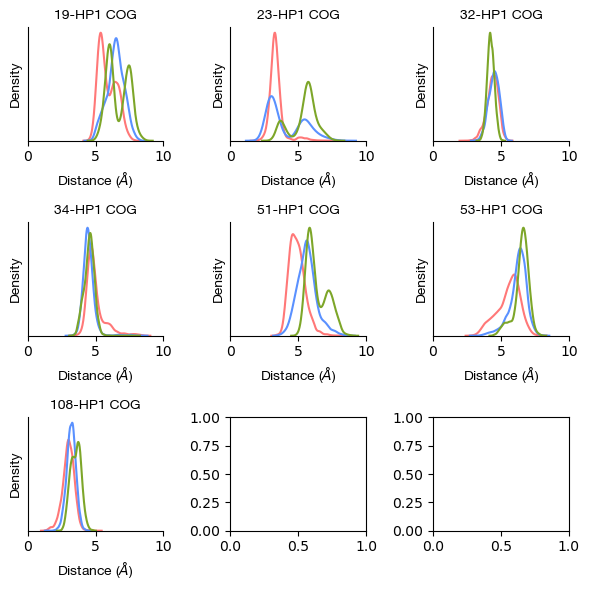

In [10]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(6, 6))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]
unb_dist_ls=[DIST_19_COG_UNB,DIST_23_COG_UNB,DIST_32_COG_UNB,
        DIST_34_COG_UNB,DIST_51_COG_UNB,DIST_53_COG_UNB,
        DIST_108_COG_UNB,MEAN_FOUR_POINT_HP1_COG_UNB]

bnd_dist_ls=[DIST_19_COG_BND,DIST_23_COG_BND,DIST_32_COG_BND,
        DIST_34_COG_BND,DIST_51_COG_BND,DIST_53_COG_BND,
        DIST_108_COG_BND,MEAN_FOUR_POINT_HP1_COG_BND]

pre_dist_ls=[DIST_19_COG_PRE,DIST_23_COG_PRE,DIST_32_COG_PRE,
        DIST_34_COG_PRE,DIST_51_COG_PRE,DIST_53_COG_PRE,
        DIST_108_COG_PRE,MEAN_FOUR_POINT_HP1_COG_PRE]

for ax_t, pre_d, unb_d, bnd_d,P_R in zip(axes_ls,pre_dist_ls,
                                         unb_dist_ls,bnd_dist_ls,HP1):

        sns.kdeplot(pre_d,
                   color='#FF7878',label='proLC3B',ax=ax_t)
        sns.kdeplot(unb_d,
                   color='#5A91FF',label='LC3BII Unbound',ax=ax_t)
        sns.kdeplot(bnd_d,
                   color='#7DA629',label='LC3BII Bound',ax=ax_t)

        ax_t.tick_params(labelsize=10)
        ax_t.spines['top'].set_visible(False)
        ax_t.spines['right'].set_visible(False)

        ax_t.set_title('%d-HP1 COG'%P_R, fontdict=font)
        ax_t.set_xlabel('Distance ($\AA$)', fontdict=font)
        ax_t.set_ylabel('Density', fontdict=font)

        ax_t.set_yticks([])
        ax_t.set_xlim(0,10)
        # plt.legend(prop=rs)

plt.tight_layout()
plt.savefig('../../plots/pocket_volume/POCKET_RESI_HP1_CENTER_DIST.png',dpi=650,
           bbox_inches='tight')
plt.show()

In [11]:
# correlation of distances with pocket volume

In [12]:
#unb
HP1_UNB_VOL_S1=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM1-HP1.csv',
                      index_col=0)
HP1_UNB_VOL_S2=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM2-HP1.csv',
                      index_col=0)
HP1_UNB_VOL_S3=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM3-HP1.csv',
                      index_col=0)

#bnd
HP1_BND_VOL_S1=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM1-HP1.csv',
                      index_col=0)
HP1_BND_VOL_S2=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM2-HP1.csv',
                      index_col=0)
HP1_BND_VOL_S3=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM3-HP1.csv',
                      index_col=0)

# pre 

HP1_PRO_VOL_S1=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM1-HP1.csv',
                      index_col=0)
HP1_PRO_VOL_S2=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM2-HP1.csv',
                      index_col=0)
HP1_PRO_VOL_S3=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM3-HP1.csv',
                      index_col=0)

#-----------------
#FINAL LIST
HP1_UNB_VOL_ALL=HP1_UNB_VOL_S1[' VOLUME (A^3) '].to_list()+HP1_UNB_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP1_UNB_VOL_S3[' VOLUME (A^3) '].to_list()

HP1_BND_VOL_ALL=HP1_BND_VOL_S1[' VOLUME (A^3) '].to_list()+HP1_BND_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP1_BND_VOL_S3[' VOLUME (A^3) '].to_list()

HP1_PRE_VOL_ALL=HP1_PRO_VOL_S1[' VOLUME (A^3) '].to_list()+HP1_PRO_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP1_PRO_VOL_S3[' VOLUME (A^3) '].to_list()


In [13]:
len(HP1_UNB_VOL_S1)

1001

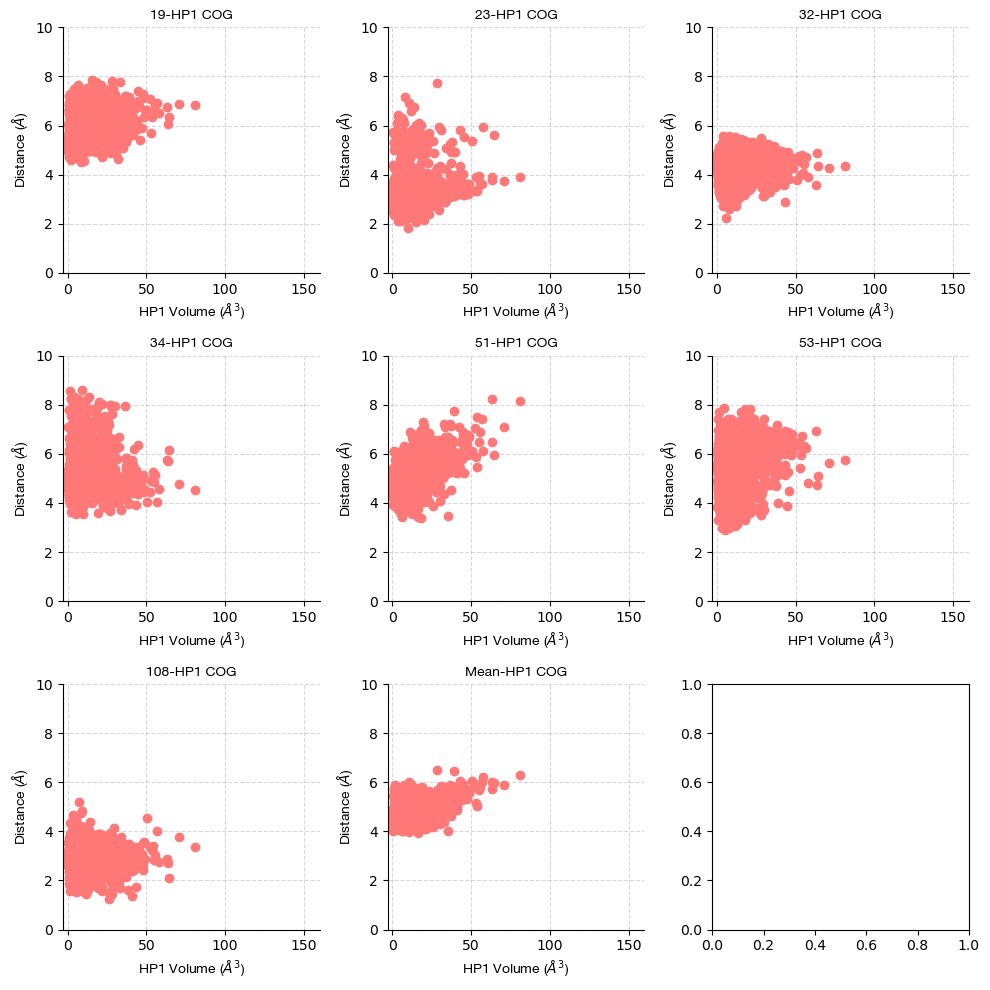

In [14]:
vol_ls=[HP1_PRE_VOL_ALL]

type_dists=[pre_dist_ls]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP1_dists=['19','23','32','34','51','53','108','Mean']
colors=['#FF7878']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP1_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP1 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)

            ax_t.set_xlim(-3,160)
            ax_t.set_ylim(0,10)

            # plt.legend(prop=rs)


plt.tight_layout()

plt.savefig('../../plots/pocket_volume/PRE_POCKET_VOL_VS_HP1_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

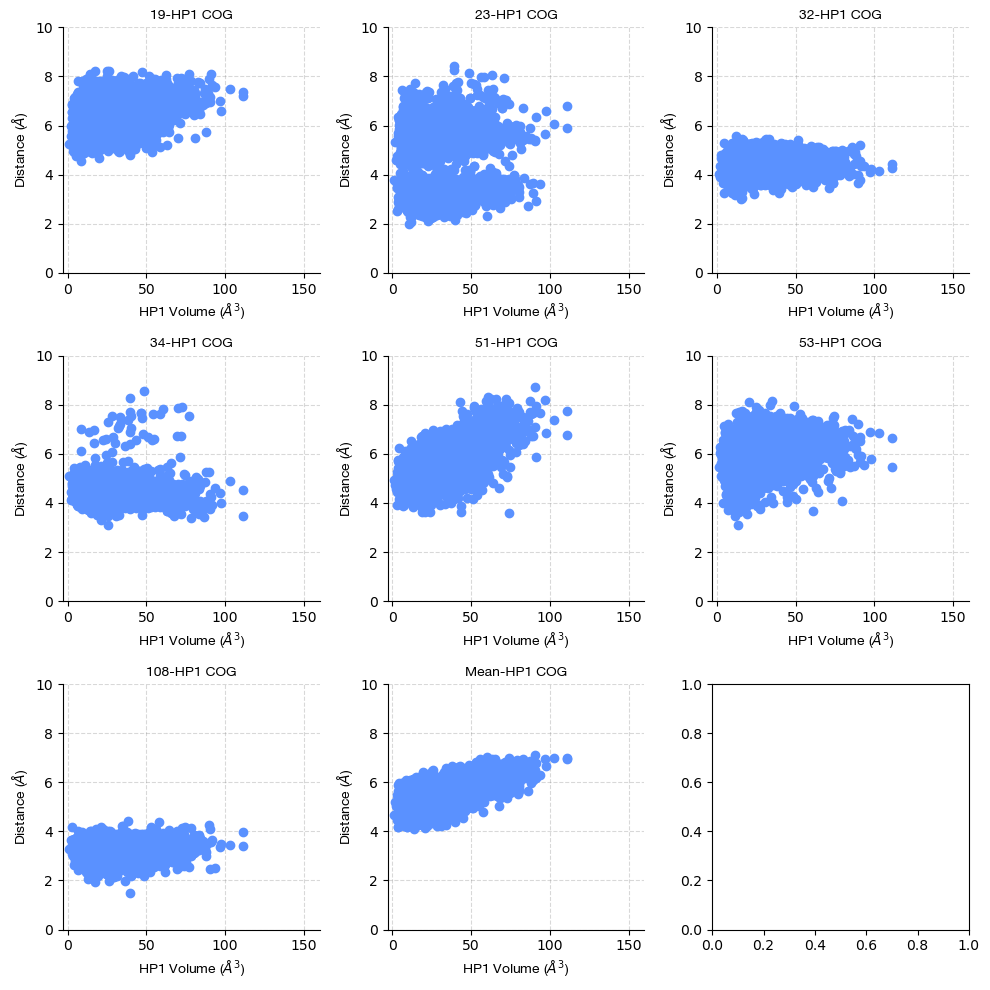

In [15]:
vol_ls=[HP1_UNB_VOL_ALL]


type_dists=[unb_dist_ls]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP1_dists=['19','23','32','34','51','53','108','Mean']
colors=['#5A91FF']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP1_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP1 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)
            
            ax_t.set_xlim(-3,160)
            ax_t.set_ylim(0,10)
            # ax_t.set_yticklabels([])
            # plt.legend(prop=rs)

plt.tight_layout()
plt.savefig('../../plots/pocket_volume/UNB_POCKET_VOL_VS_HP1_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

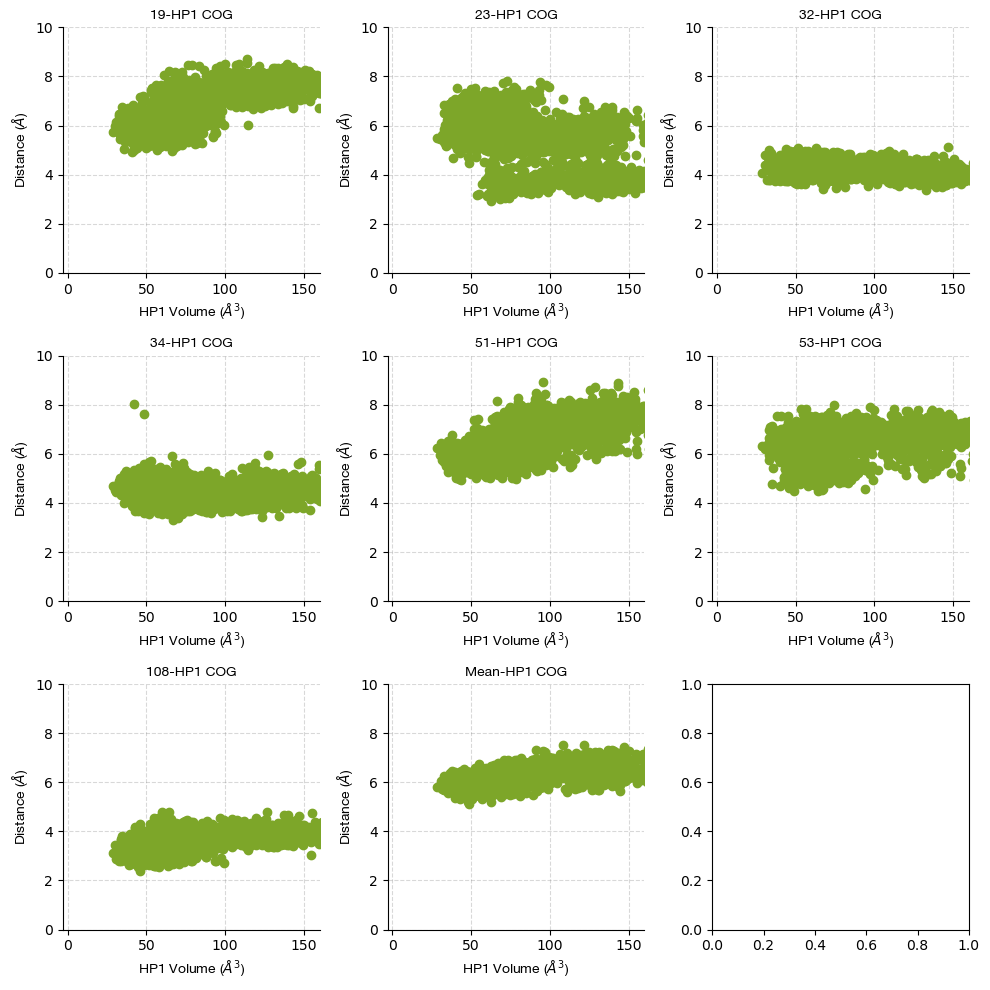

In [16]:
vol_ls=[HP1_BND_VOL_ALL]


type_dists=[bnd_dist_ls]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP1_dists=['19','23','32','34','51','53','108','Mean']
colors=['#7DA629']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP1_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP1 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)
            
            ax_t.set_xlim(-3,160)
            ax_t.set_ylim(0,10)
            # ax_t.set_yticklabels([])
            # plt.legend(prop=rs)
plt.tight_layout()
plt.savefig('../../plots/pocket_volume/BND_POCKET_VOL_VS_HP1_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

In [17]:
import scipy
# PEARSON CORRELATION COEFFICIENT with scipy
def corr_val(a,b):
    regg=scipy.stats.linregress(a, b)
    corr=scipy.stats.pearsonr(a,b)[0]
    slope_=regg.slope
    inter=regg.intercept
    
    
    reg_=[]
    for i in a:
        reg_line=inter + (slope_ *i)
        reg_.append(reg_line)
    
    return corr, reg_


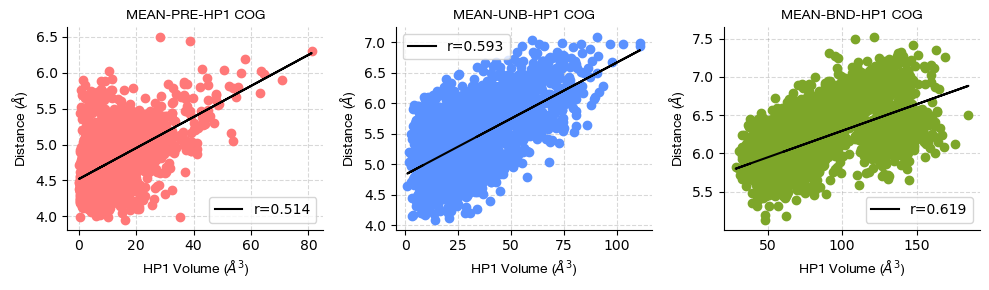

In [18]:
#MEAN_FOUR_POINT_DISTANCE_HP1

vol_ls=[HP1_PRE_VOL_ALL,HP1_UNB_VOL_ALL,HP1_BND_VOL_ALL]

mean_dist_ls=[MEAN_FOUR_POINT_HP1_COG_PRE, MEAN_FOUR_POINT_HP1_COG_UNB,MEAN_FOUR_POINT_HP1_COG_BND]
HP1_dists_MEAN=['MEAN-PRE','MEAN-UNB','MEAN-BND']
colors=['#FF7878','#5A91FF','#7DA629']
fig, ((ax1, ax2, ax3)) = plt.subplots(1,3, figsize=(10, 3))




ax1.set_axisbelow(True)
ax1.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax1.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax1.scatter(vol_ls[0],mean_dist_ls[0],
           color=colors[0])
corr_=corr_val(vol_ls[0],mean_dist_ls[0])
ax1.plot(vol_ls[0], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax1.tick_params(labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.set_title('%s-HP1 COG'%HP1_dists_MEAN[0], fontdict=font)
ax1.set_ylabel('Distance ($\AA$)', fontdict=font)
ax1.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)


ax2.set_axisbelow(True)
ax2.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax2.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax2.scatter(vol_ls[1],mean_dist_ls[1],
           color=colors[1])
corr_=corr_val(vol_ls[1],mean_dist_ls[1])
ax2.plot(vol_ls[1], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax2.tick_params(labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.set_title('%s-HP1 COG'%HP1_dists_MEAN[1], fontdict=font)
ax2.set_ylabel('Distance ($\AA$)', fontdict=font)
ax2.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)


ax3.set_axisbelow(True)
ax3.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax3.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax3.scatter(vol_ls[2],mean_dist_ls[2],
           color=colors[2])
corr_=corr_val(vol_ls[2],mean_dist_ls[2])
ax3.plot(vol_ls[2], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax3.tick_params(labelsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax3.set_title('%s-HP1 COG'%HP1_dists_MEAN[2], fontdict=font)
ax3.set_ylabel('Distance ($\AA$)', fontdict=font)
ax3.set_xlabel('HP1 Volume ($\AA^3$)', fontdict=font)


# ax_t.set_yticklabels([])
ax1.legend()
ax2.legend()
ax3.legend()
plt.tight_layout()
plt.savefig('../../plots/pocket_volume/POCKET_VOL_VS_MEAN_HP1_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')

In [19]:
HP1_dists[-1]='Mean (19,23,51)'
pre_dist_dat=pd.DataFrame(pre_dist_ls)
pre_dist_dat=pre_dist_dat.T
pre_dist_dat.columns=HP1_dists
pre_dist_dat.to_csv("../../data/pocket_volume/PRE/pre_hp1_point_distances.csv")

In [20]:
unb_dist_dat=pd.DataFrame(unb_dist_ls)
unb_dist_dat=unb_dist_dat.T
unb_dist_dat.columns=HP1_dists
unb_dist_dat.to_csv("../../data/pocket_volume/UNB/unb_hp1_point_distances.csv")

In [21]:
bnd_dist_dat=pd.DataFrame(bnd_dist_ls)
bnd_dist_dat=bnd_dist_dat.T
bnd_dist_dat.columns=HP1_dists
bnd_dist_dat.to_csv("../../data/pocket_volume/BND/bnd_hp1_point_distances.csv")

# HP2

In [13]:
HP2=[35,52,54,55,58,63,66,67,70]
# terminal_atoms=['CD1','CZ','CG2','CG','CG2','CD1','CD1','CD1','NH1']
terminal_atoms_sim=['CD','CZ','CG2','CG','CG2','CD1','CD','CD','NH1']
def four_point_dist_HP2(traj):
    total_frames=len(traj.trajectory)
    n1=len(HP2)
    dist_sum = np.zeros((n1, n1))
    
    dis_35_C_ls=[]
    dis_52_C_ls=[]
    dis_54_C_ls=[]
    dis_55_C_ls=[]
    dis_58_C_ls=[]
    dis_63_C_ls=[]
    dis_66_C_ls=[]
    dis_67_C_ls=[]
    dis_70_C_ls=[]
    mean_HP2_four_point=[]
    mean_HP2_all=[]
    
    for ts in tqdm.tqdm(traj.trajectory):
        SC_COG_HP2=[]
        pocket_COG=[]
        sel2=traj.select_atoms('resid 35 or resid 52 or resid 54 or resid 55 or resid 58 or resid 63 or resid 66 or resid 67 or resid 70').center_of_geometry()
        pocket_COG.append(sel2)
        
        for i,j in zip (HP2,terminal_atoms_sim):
            sel1 = traj.select_atoms( 'resid %d and name %s'%(i,j)).center_of_geometry()
            SC_COG_HP2.append(sel1)
        
        SC_COG_HP2=np.asarray(SC_COG_HP2)
        pocket_COG=np.asarray(pocket_COG)
        ts_dist = distance.cdist(pocket_COG,SC_COG_HP2, 'euclidean')
        ts_dist=np.transpose(ts_dist)

        dis_35_C=ts_dist[0,0]
        dis_52_C=ts_dist[1,0]
        dis_54_C=ts_dist[2,0]
        dis_55_C=ts_dist[3,0]
        dis_58_C=ts_dist[4,0]
        dis_63_C=ts_dist[5,0]
        dis_66_C=ts_dist[6,0]
        dis_67_C=ts_dist[7,0]
        dis_70_C=ts_dist[8,0]

#         sum_four_point=dis_35_C+dis_52_C+dis_54_C+dis_66_C
        sum_four_point=dis_35_C+dis_52_C+dis_70_C+dis_66_C
        mean_four_point=sum_four_point/4

        sum_all=dis_35_C+dis_52_C+dis_54_C+dis_55_C+dis_58_C+dis_66_C+dis_67_C+dis_70_C
        mean_all=sum_all/9

        dis_35_C_ls.append(dis_35_C)
        dis_52_C_ls.append(dis_52_C)
        dis_54_C_ls.append(dis_54_C)
        dis_55_C_ls.append(dis_55_C)
        dis_58_C_ls.append(dis_58_C)
        dis_63_C_ls.append(dis_63_C)
        dis_66_C_ls.append(dis_66_C)
        dis_67_C_ls.append(dis_67_C)
        dis_70_C_ls.append(dis_70_C)

        mean_HP2_four_point.append(mean_four_point)
        mean_HP2_all.append(mean_all)
        
    return(dis_35_C_ls,dis_52_C_ls,dis_54_C_ls,dis_55_C_ls,dis_58_C_ls,dis_63_C_ls,
           dis_66_C_ls,dis_67_C_ls,dis_70_C_ls,mean_HP2_four_point)

In [14]:
dist_35_COG_HP2_PRE_S1,dist_52_COG_HP2_PRE_S1,dist_54_COG_HP2_PRE_S1,\
dist_55_COG_HP2_PRE_S1,dist_58_COG_HP2_PRE_S1,dist_63_COG_HP2_PRE_S1,\
dist_66_COG_HP2_PRE_S1,dist_67_COG_HP2_PRE_S1,dist_70_COG_HP2_PRE_S1,dist_four_point_HP2_PRE_S1=four_point_dist_HP2(u_unbound_pre_S1)

dist_35_COG_HP2_PRE_S2,dist_52_COG_HP2_PRE_S2,dist_54_COG_HP2_PRE_S2,\
dist_55_COG_HP2_PRE_S2,dist_58_COG_HP2_PRE_S2,dist_63_COG_HP2_PRE_S2,\
dist_66_COG_HP2_PRE_S2,dist_67_COG_HP2_PRE_S2,dist_70_COG_HP2_PRE_S2,dist_four_point_HP2_PRE_S2=four_point_dist_HP2(u_unbound_pre_S2)


dist_35_COG_HP2_PRE_S3,dist_52_COG_HP2_PRE_S3,dist_54_COG_HP2_PRE_S3,\
dist_55_COG_HP2_PRE_S3,dist_58_COG_HP2_PRE_S3,dist_63_COG_HP2_PRE_S3,\
dist_66_COG_HP2_PRE_S3,dist_67_COG_HP2_PRE_S3,dist_70_COG_HP2_PRE_S3,dist_four_point_HP2_PRE_S3=four_point_dist_HP2(u_unbound_pre_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:04<00:00, 245.70it/s]


In [15]:
dist_35_COG_HP2_UNB_S1,dist_52_COG_HP2_UNB_S1,dist_54_COG_HP2_UNB_S1,\
dist_55_COG_HP2_UNB_S1,dist_58_COG_HP2_UNB_S1,dist_63_COG_HP2_UNB_S1,\
dist_66_COG_HP2_UNB_S1,dist_67_COG_HP2_UNB_S1,dist_70_COG_HP2_UNB_S1,dist_four_point_HP2_UNB_S1=four_point_dist_HP2(u_unbound_ER_S1)

dist_35_COG_HP2_UNB_S2,dist_52_COG_HP2_UNB_S2,dist_54_COG_HP2_UNB_S2,\
dist_55_COG_HP2_UNB_S2,dist_58_COG_HP2_UNB_S2,dist_63_COG_HP2_UNB_S2,\
dist_66_COG_HP2_UNB_S2,dist_67_COG_HP2_UNB_S2,dist_70_COG_HP2_UNB_S2,dist_four_point_HP2_UNB_S2=four_point_dist_HP2(u_unbound_ER_S2)


dist_35_COG_HP2_UNB_S3,dist_52_COG_HP2_UNB_S3,dist_54_COG_HP2_UNB_S3,\
dist_55_COG_HP2_UNB_S3,dist_58_COG_HP2_UNB_S3,dist_63_COG_HP2_UNB_S3,\
dist_66_COG_HP2_UNB_S3,dist_67_COG_HP2_UNB_S3,dist_70_COG_HP2_UNB_S3,dist_four_point_HP2_UNB_S3=four_point_dist_HP2(u_unbound_ER_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:03<00:00, 282.12it/s]


In [16]:
dist_35_COG_HP2_BND_S1,dist_52_COG_HP2_BND_S1,dist_54_COG_HP2_BND_S1,\
dist_55_COG_HP2_BND_S1,dist_58_COG_HP2_BND_S1,dist_63_COG_HP2_BND_S1,\
dist_66_COG_HP2_BND_S1,dist_67_COG_HP2_BND_S1,dist_70_COG_HP2_BND_S1,dist_four_point_HP2_BND_S1=four_point_dist_HP2(u_bound_ER_S1)

dist_35_COG_HP2_BND_S2,dist_52_COG_HP2_BND_S2,dist_54_COG_HP2_BND_S2,\
dist_55_COG_HP2_BND_S2,dist_58_COG_HP2_BND_S2,dist_63_COG_HP2_BND_S2,\
dist_66_COG_HP2_BND_S2,dist_67_COG_HP2_BND_S2,dist_70_COG_HP2_BND_S2,dist_four_point_HP2_BND_S2=four_point_dist_HP2(u_bound_ER_S2)


dist_35_COG_HP2_BND_S3,dist_52_COG_HP2_BND_S3,dist_54_COG_HP2_BND_S3,\
dist_55_COG_HP2_BND_S3,dist_58_COG_HP2_BND_S3,dist_63_COG_HP2_BND_S3,\
dist_66_COG_HP2_BND_S3,dist_67_COG_HP2_BND_S3,dist_70_COG_HP2_BND_S3,dist_four_point_HP2_BND_S3=four_point_dist_HP2(u_bound_ER_S3)


100%|█████████████████████████████████████████████| 1001/1001 [00:03<00:00, 264.87it/s]


In [17]:
DIST_35_COG_PRE=dist_35_COG_HP2_PRE_S1+dist_35_COG_HP2_PRE_S2+dist_35_COG_HP2_PRE_S3
DIST_52_COG_PRE=dist_52_COG_HP2_PRE_S1+dist_52_COG_HP2_PRE_S2+dist_52_COG_HP2_PRE_S3
DIST_54_COG_PRE=dist_54_COG_HP2_PRE_S1+dist_54_COG_HP2_PRE_S2+dist_54_COG_HP2_PRE_S3
DIST_55_COG_PRE=dist_55_COG_HP2_PRE_S1+dist_55_COG_HP2_PRE_S2+dist_55_COG_HP2_PRE_S3
DIST_58_COG_PRE=dist_58_COG_HP2_PRE_S1+dist_58_COG_HP2_PRE_S2+dist_58_COG_HP2_PRE_S3
DIST_63_COG_PRE=dist_63_COG_HP2_PRE_S1+dist_63_COG_HP2_PRE_S2+dist_63_COG_HP2_PRE_S3

DIST_66_COG_PRE=dist_66_COG_HP2_PRE_S1+dist_66_COG_HP2_PRE_S2+dist_66_COG_HP2_PRE_S3
DIST_67_COG_PRE=dist_67_COG_HP2_PRE_S1+dist_67_COG_HP2_PRE_S2+dist_67_COG_HP2_PRE_S3
DIST_70_COG_PRE=dist_70_COG_HP2_PRE_S1+dist_70_COG_HP2_PRE_S2+dist_70_COG_HP2_PRE_S3

MEAN_FOUR_POINT_HP2_COG_PRE=dist_four_point_HP2_PRE_S1+dist_four_point_HP2_PRE_S2+dist_four_point_HP2_PRE_S3

In [18]:
DIST_35_COG_UNB=dist_35_COG_HP2_UNB_S1+dist_35_COG_HP2_UNB_S2+dist_35_COG_HP2_UNB_S3
DIST_52_COG_UNB=dist_52_COG_HP2_UNB_S1+dist_52_COG_HP2_UNB_S2+dist_52_COG_HP2_UNB_S3
DIST_54_COG_UNB=dist_54_COG_HP2_UNB_S1+dist_54_COG_HP2_UNB_S2+dist_54_COG_HP2_UNB_S3
DIST_55_COG_UNB=dist_55_COG_HP2_UNB_S1+dist_55_COG_HP2_UNB_S2+dist_55_COG_HP2_UNB_S3
DIST_58_COG_UNB=dist_58_COG_HP2_UNB_S1+dist_58_COG_HP2_UNB_S2+dist_58_COG_HP2_UNB_S3
DIST_63_COG_UNB=dist_63_COG_HP2_UNB_S1+dist_63_COG_HP2_UNB_S2+dist_63_COG_HP2_UNB_S3

DIST_66_COG_UNB=dist_66_COG_HP2_UNB_S1+dist_66_COG_HP2_UNB_S2+dist_66_COG_HP2_UNB_S3
DIST_67_COG_UNB=dist_67_COG_HP2_UNB_S1+dist_67_COG_HP2_UNB_S2+dist_67_COG_HP2_UNB_S3
DIST_70_COG_UNB=dist_70_COG_HP2_UNB_S1+dist_70_COG_HP2_UNB_S2+dist_70_COG_HP2_UNB_S3

MEAN_FOUR_POINT_HP2_COG_UNB=dist_four_point_HP2_UNB_S1+dist_four_point_HP2_UNB_S2+dist_four_point_HP2_UNB_S3

In [19]:
DIST_35_COG_BND=dist_35_COG_HP2_BND_S1+dist_35_COG_HP2_BND_S2+dist_35_COG_HP2_BND_S3
DIST_52_COG_BND=dist_52_COG_HP2_BND_S1+dist_52_COG_HP2_BND_S2+dist_52_COG_HP2_BND_S3
DIST_54_COG_BND=dist_54_COG_HP2_BND_S1+dist_54_COG_HP2_BND_S2+dist_54_COG_HP2_BND_S3
DIST_55_COG_BND=dist_55_COG_HP2_BND_S1+dist_55_COG_HP2_BND_S2+dist_55_COG_HP2_BND_S3
DIST_58_COG_BND=dist_58_COG_HP2_BND_S1+dist_58_COG_HP2_BND_S2+dist_58_COG_HP2_BND_S3
DIST_63_COG_BND=dist_63_COG_HP2_BND_S1+dist_63_COG_HP2_BND_S2+dist_63_COG_HP2_BND_S3

DIST_66_COG_BND=dist_66_COG_HP2_BND_S1+dist_66_COG_HP2_BND_S2+dist_66_COG_HP2_BND_S3
DIST_67_COG_BND=dist_67_COG_HP2_BND_S1+dist_67_COG_HP2_BND_S2+dist_67_COG_HP2_BND_S3
DIST_70_COG_BND=dist_70_COG_HP2_BND_S1+dist_70_COG_HP2_BND_S2+dist_70_COG_HP2_BND_S3

MEAN_FOUR_POINT_HP2_COG_BND=dist_four_point_HP2_BND_S1+dist_four_point_HP2_BND_S2+dist_four_point_HP2_BND_S3

In [20]:
HP2_PRE_dist_dat=pd.DataFrame([DIST_35_COG_PRE,DIST_52_COG_PRE,DIST_54_COG_PRE,DIST_55_COG_PRE,\
                              DIST_58_COG_PRE,DIST_63_COG_PRE,DIST_66_COG_PRE,DIST_67_COG_PRE,
                              DIST_70_COG_PRE])
HP2_UNB_dist_dat=pd.DataFrame([DIST_35_COG_UNB,DIST_52_COG_UNB,DIST_54_COG_UNB,DIST_55_COG_UNB,\
                              DIST_58_COG_UNB,DIST_63_COG_UNB,DIST_66_COG_UNB,DIST_67_COG_UNB,
                              DIST_70_COG_UNB])



In [21]:
HP1_PRE_dist_dat.to_csv("../../scripts/pocket_volume/distance_from_hp1_center_pre.csv")
HP2_PRE_dist_dat.to_csv("../../scripts/pocket_volume/distance_from_hp2_center_pre.csv")

HP1_UNB_dist_dat.to_csv("../../scripts/pocket_volume/distance_from_hp1_center_unb.csv")
HP2_UNB_dist_dat.to_csv("../../scripts/pocket_volume/distance_from_hp2_center_unb.csv")

In [22]:
for i,j,z in zip ((HP2_UNB_dist_dat.T).mean(),
                (HP2_PRE_dist_dat.T).mean(), HP2):
    
    print(z, j-i)#pre-unb; neg--> larger dist in Unb, pos--> smaller dist in Unb
#     if abs(j-i)>0.5:
#         print("NOTE %d"%z)

35 -1.1731016927184132
52 0.9955606027875827
54 0.46431632812550916
55 0.5503460510517453
58 0.13678548241253807
63 0.45819532028749377
66 -0.8395683954640463
67 0.6785611379509673
70 0.31731233572085316


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

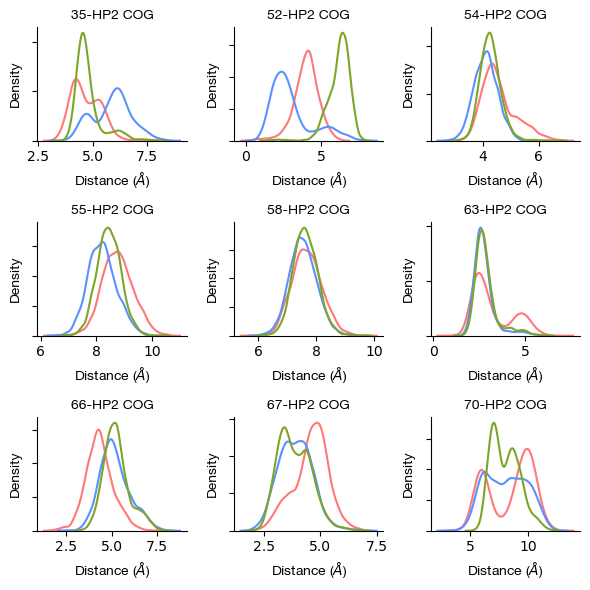

In [29]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(6, 6))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]
unb_dist_ls=[DIST_35_COG_UNB,DIST_52_COG_UNB,DIST_54_COG_UNB,
             DIST_55_COG_UNB,DIST_58_COG_UNB,DIST_63_COG_UNB,DIST_66_COG_UNB,
             DIST_67_COG_UNB,DIST_70_COG_UNB,MEAN_FOUR_POINT_HP2_COG_UNB]
bnd_dist_ls=[DIST_35_COG_BND,DIST_52_COG_BND,DIST_54_COG_BND,
             DIST_55_COG_BND,DIST_58_COG_BND,DIST_63_COG_BND,DIST_66_COG_BND,
             DIST_67_COG_BND,DIST_70_COG_BND,MEAN_FOUR_POINT_HP2_COG_BND]
pre_dist_ls=[DIST_35_COG_PRE,DIST_52_COG_PRE,DIST_54_COG_PRE,
             DIST_55_COG_PRE,DIST_58_COG_PRE,DIST_63_COG_PRE,DIST_66_COG_PRE,
             DIST_67_COG_PRE,DIST_70_COG_PRE,MEAN_FOUR_POINT_HP2_COG_PRE]



for ax_t, pre_d, unb_d, bnd_d,P_R in zip(axes_ls,pre_dist_ls,
                                         unb_dist_ls,bnd_dist_ls,HP2):

        sns.kdeplot(pre_d,
                   color='#FF7878',label='proLC3B',ax=ax_t)
        sns.kdeplot(unb_d,
                   color='#5A91FF',label='LC3BII Unbound',ax=ax_t)
        sns.kdeplot(bnd_d,
                   color='#7DA629',label='LC3BII Bound',ax=ax_t)

        ax_t.tick_params(labelsize=10)
        ax_t.spines['top'].set_visible(False)
        ax_t.spines['right'].set_visible(False)

        ax_t.set_title('%d-HP2 COG'%P_R, fontdict=font)
        ax_t.set_xlabel('Distance ($\AA$)', fontdict=font)
        ax_t.set_ylabel('Density', fontdict=font)

        ax_t.set_yticklabels([])
        # plt.legend(prop=rs)

plt.tight_layout()
plt.savefig('../../plots/pocket_volume/POCKET_RESI_HP2_CENTER_DIST.png',dpi=650,
           bbox_inches='tight')
plt.show()

In [30]:
#unb
HP2_UNB_VOL_S1=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM1-HP2.csv',
                      index_col=0)
HP2_UNB_VOL_S2=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM2-HP2.csv',
                      index_col=0)
HP2_UNB_VOL_S3=pd.read_csv('../../data/pocket_volume/UNB/LC3B-ER-PV-SIM3-HP2.csv',
                      index_col=0)

#bnd
HP2_BND_VOL_S1=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM1-HP2.csv',
                      index_col=0)
HP2_BND_VOL_S2=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM2-HP2.csv',
                      index_col=0)
HP2_BND_VOL_S3=pd.read_csv('../../data/pocket_volume/BND/LC3B-p62-ER-PV-SIM3-HP2.csv',
                      index_col=0)

# pre 

HP2_PRO_VOL_S1=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM1-HP2.csv',
                      index_col=0)
HP2_PRO_VOL_S2=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM2-HP2.csv',
                      index_col=0)
HP2_PRO_VOL_S3=pd.read_csv('../../data/pocket_volume/PRE/proLC3B-OPLS-PV-SIM3-HP2.csv',
                      index_col=0)

#-----------------
#FINAL LIST
HP2_UNB_VOL_ALL=HP2_UNB_VOL_S1[' VOLUME (A^3) '].to_list()+HP2_UNB_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP2_UNB_VOL_S3[' VOLUME (A^3) '].to_list()

HP2_BND_VOL_ALL=HP2_BND_VOL_S1[' VOLUME (A^3) '].to_list()+HP2_BND_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP2_BND_VOL_S3[' VOLUME (A^3) '].to_list()

HP2_PRE_VOL_ALL=HP2_PRO_VOL_S1[' VOLUME (A^3) '].to_list()+HP2_PRO_VOL_S2[' VOLUME (A^3) '].to_list()+\
HP2_PRO_VOL_S3[' VOLUME (A^3) '].to_list()


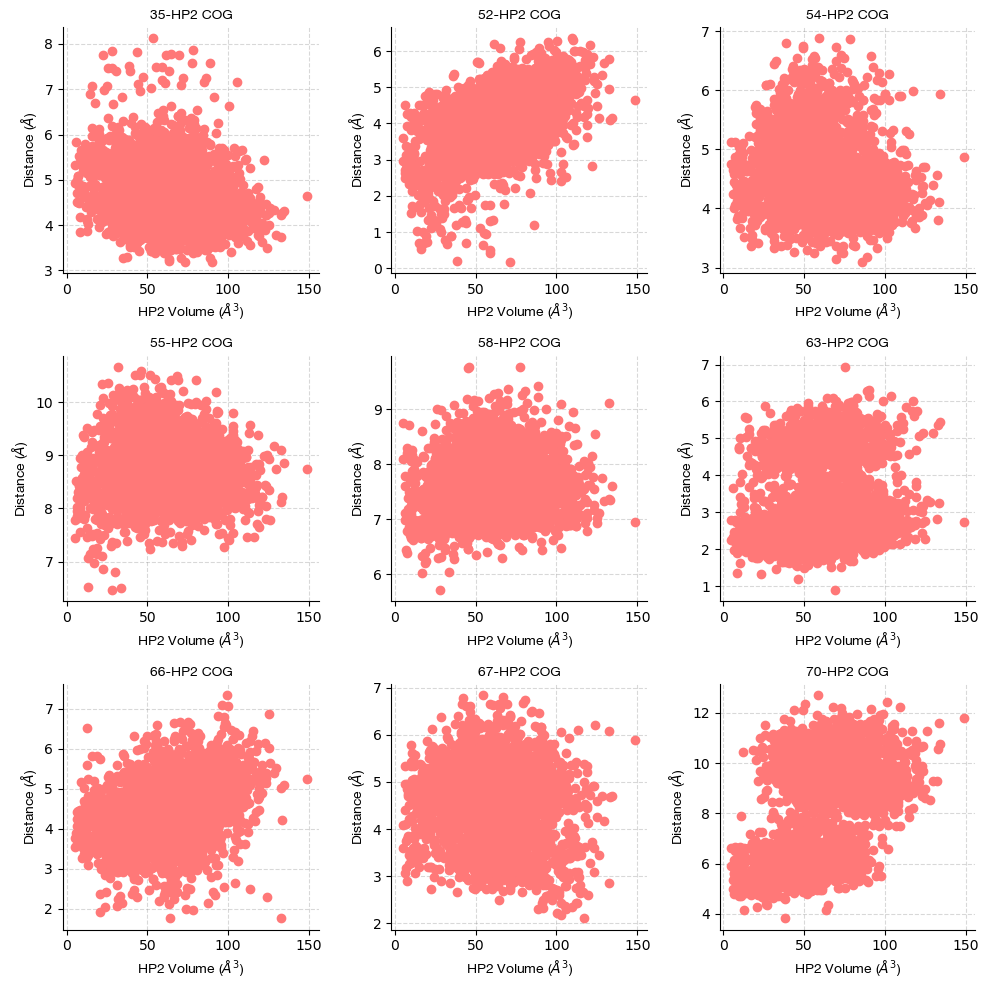

In [31]:
vol_ls=[HP2_PRE_VOL_ALL]

type_dists=[pre_dist_ls[:-1]]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP2_dists=['35','52','54','55','58','63','66','67','70','Mean']
colors=['#FF7878']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP2_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP2 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)

#             ax_t.set_xlim((min(vol),max(vol)))
            # plt.legend(prop=rs)

plt.tight_layout()

plt.savefig('../../plots/pocket_volume/PRE_POCKET_VOL_VS_HP2_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

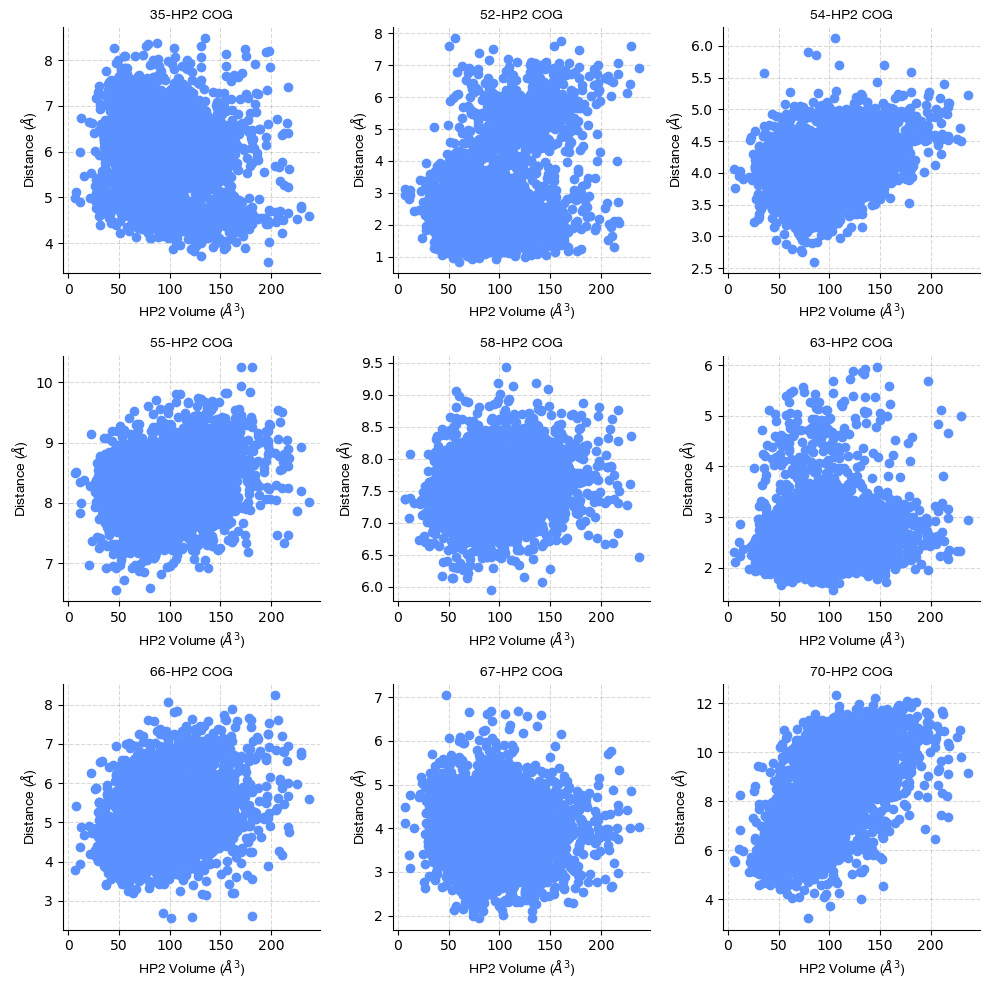

In [32]:
vol_ls=[HP2_UNB_VOL_ALL]


type_dists=[unb_dist_ls[:-1]]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP2_dists=['35','52','54','55','58','63','66','67','70','Mean']
colors=['#5A91FF']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP2_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP2 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)
            
            # ax_t.set_yticklabels([])
            # plt.legend(prop=rs)

plt.tight_layout()
plt.savefig('../../plots/pocket_volume/UNB_POCKET_VOL_VS_HP2_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

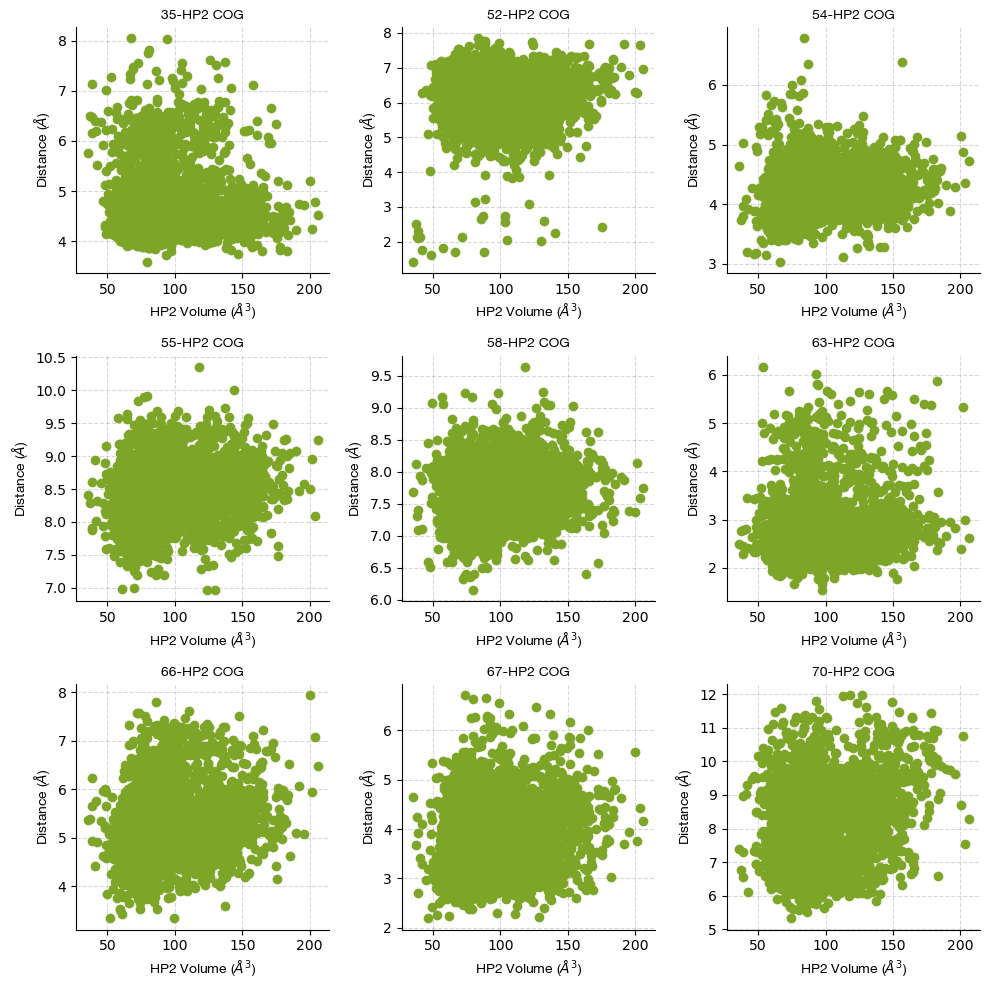

In [33]:
vol_ls=[HP2_BND_VOL_ALL]


type_dists=[bnd_dist_ls[:-1]]


font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(10, 10))


axes_ls=[ax1,ax2,ax3,ax4,ax5,ax6,ax7, ax8, ax9]

HP2_dists=['35','52','54','55','58','63','66','67','70','Mean']
colors=['#7DA629']

v_counter=-1
for vol in vol_ls:
    v_counter=v_counter+1
    col=colors[v_counter]
    
    for R_dist in type_dists:
        d_counter=-1
        for R_sub_dist in R_dist:
            d_counter=d_counter+1

            ax_t=axes_ls[d_counter]
            P_R=HP2_dists[d_counter]
            
            ax_t.set_axisbelow(True)
            ax_t.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
            ax_t.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

            ax_t.scatter(vol,R_sub_dist,
                       color=col)

            ax_t.tick_params(labelsize=10)
            ax_t.spines['top'].set_visible(False)
            ax_t.spines['right'].set_visible(False)

            ax_t.set_title('%s-HP2 COG'%P_R, fontdict=font)
            ax_t.set_ylabel('Distance ($\AA$)', fontdict=font)
            ax_t.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)
            
            # ax_t.set_yticklabels([])
            # plt.legend(prop=rs)
plt.tight_layout()
plt.savefig('../../plots/pocket_volume/BND_POCKET_VOL_VS_HP2_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')
plt.show()

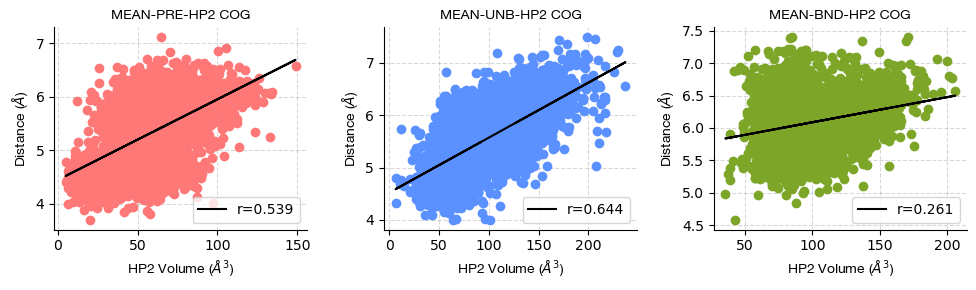

In [34]:
#MEAN_FOUR_POINT_DISTANCE_HP2

vol_ls=[HP2_PRE_VOL_ALL,HP2_UNB_VOL_ALL,HP2_BND_VOL_ALL]

mean_dist_ls=[MEAN_FOUR_POINT_HP2_COG_PRE, MEAN_FOUR_POINT_HP2_COG_UNB,MEAN_FOUR_POINT_HP2_COG_BND]
HP2_dists_MEAN=['MEAN-PRE','MEAN-UNB','MEAN-BND']
colors=['#FF7878','#5A91FF','#7DA629']
fig, ((ax1, ax2, ax3)) = plt.subplots(1,3, figsize=(10, 3))




ax1.set_axisbelow(True)
ax1.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax1.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax1.scatter(vol_ls[0],mean_dist_ls[0],
           color=colors[0])
corr_=corr_val(vol_ls[0],mean_dist_ls[0])
ax1.plot(vol_ls[0], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax1.tick_params(labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.set_title('%s-HP2 COG'%HP2_dists_MEAN[0], fontdict=font)
ax1.set_ylabel('Distance ($\AA$)', fontdict=font)
ax1.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)


ax2.set_axisbelow(True)
ax2.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax2.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax2.scatter(vol_ls[1],mean_dist_ls[1],
           color=colors[1])
corr_=corr_val(vol_ls[1],mean_dist_ls[1])
ax2.plot(vol_ls[1], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax2.tick_params(labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.set_title('%s-HP2 COG'%HP2_dists_MEAN[1], fontdict=font)
ax2.set_ylabel('Distance ($\AA$)', fontdict=font)
ax2.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)


ax3.set_axisbelow(True)
ax3.yaxis.grid(color='gray', linestyle='dashed',alpha=0.3)
ax3.xaxis.grid(color='gray', linestyle='dashed',alpha=0.3)

ax3.scatter(vol_ls[2],mean_dist_ls[2],
           color=colors[2])
corr_=corr_val(vol_ls[2],mean_dist_ls[2])
ax3.plot(vol_ls[2], corr_[1],color='black',
         label='r=%0.3f'%corr_[0])
ax3.tick_params(labelsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax3.set_title('%s-HP2 COG'%HP2_dists_MEAN[2], fontdict=font)
ax3.set_ylabel('Distance ($\AA$)', fontdict=font)
ax3.set_xlabel('HP2 Volume ($\AA^3$)', fontdict=font)


# ax_t.set_yticklabels([])
ax1.legend()
ax2.legend()
ax3.legend()
plt.tight_layout()
plt.savefig('../../plots/pocket_volume/POCKET_VOL_VS_MEAN_HP2_DIST_CORRELATION.png',dpi=650,
           bbox_inches='tight')

In [35]:
HP2_dists[-1]='Mean (35,52,70,66)'
pre_dist_dat=pd.DataFrame(pre_dist_ls)
pre_dist_dat=pre_dist_dat.T
pre_dist_dat.columns=HP2_dists
pre_dist_dat.to_csv("../../data/pocket_volume/PRE/pre_hp2_point_distances.csv")

In [36]:
unb_dist_dat=pd.DataFrame(unb_dist_ls)
unb_dist_dat=unb_dist_dat.T
unb_dist_dat.columns=HP2_dists
unb_dist_dat.to_csv("../../data/pocket_volume/UNB/unb_hp2_point_distances.csv")

In [37]:
bnd_dist_dat=pd.DataFrame(bnd_dist_ls)
bnd_dist_dat=bnd_dist_dat.T
bnd_dist_dat.columns=HP2_dists
bnd_dist_dat.to_csv("../../data/pocket_volume/BND/bnd_hp2_point_distances.csv")